In [20]:
# Compute IG for each feature
features = ["Age", "Salary", "Years_of_Experience"]
results_entropy = []

for feature in features:
    ig, ig_threshold = information_gain(df, feature, "Buys_Car")
    results_entropy.append({
        "Feature": feature,
        "IG": round(ig, 3),
        "IG Threshold": ig_threshold
    })

In [21]:
# Convert results to DataFrame
results_entropy_df = pd.DataFrame(results_entropy)

In [22]:
# Print results for Entropy and Information Gain
print("Results based on Information Gain:")
print(results_entropy_df)

Results based on Information Gain:
               Feature     IG  IG Threshold
0                  Age  0.000          27.5
1               Salary  0.044       33000.0
2  Years_of_Experience  0.459           4.0


In [23]:
# Best feature based on IG
best_ig_feature = results_entropy_df.loc[results_entropy_df["IG"].idxmax()]
print("\nBest feature based on IG:", best_ig_feature["Feature"], "with threshold:", best_ig_feature["IG Threshold"])


Best feature based on IG: Years_of_Experience with threshold: 4.0


# Apply on both categorical columns

In [24]:
# Manually written dataset with categorical columns
data = {
    "Buys_Car": ['Yes', 'No', 'No', 'Yes', 'Yes', 'Yes'],  # Target variable
    "Education_Level": ["Bachelor", "Master", "Master", "PhD", "PhD", "Bachelor"],
    "Region": ["Urban", "Suburban", "Urban", "Rural", "Urban", "Suburban"],  
    "Marital_Status": ["Single", "Married", "Single", "Married", "Divorced", "Single"],  
    "Vehicle_Type": ["SUV", "Sedan", "SUV", "Truck", "Sedan", "SUV"],  
    "Employment_Status": ["Employed", "Employed", "Student", "Employed", "Unemployed", "Employed"] 
}
df = pd.DataFrame(data)

df

,Buys_Car,Education_Level,Region,Marital_Status,Vehicle_Type,Employment_Status
0,Yes,Bachelor,Urban,Single,SUV,Employed
1,No,Master,Suburban,Married,Sedan,Employed
2,No,Master,Urban,Single,SUV,Student
3,Yes,PhD,Rural,Married,Truck,Employed
4,Yes,PhD,Urban,Divorced,Sedan,Unemployed
5,Yes,Bachelor,Suburban,Single,SUV,Employed


In [25]:
# Function to calculate entropy for categorical data
def entropy(y):
    unique_classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

## **Example: Using the `Education_Level` Column**
Let's take the **Education_Level** column as an example:

```python
Education_Level = ["Bachelor", "Master", "Master", "PhD", "PhD", "Bachelor"]
```

We apply the **entropy function** to this column.

### **Step 1: Find Unique Classes and Their Counts**
```python
unique_classes, counts = np.unique(Education_Level, return_counts=True)
```
This gives:
```python
unique_classes = ['Bachelor', 'Master', 'PhD']
counts = [2, 2, 2]
```
Explanation:
- "Bachelor" appears **2 times**.
- "Master" appears **2 times**.
- "PhD" appears **2 times**.

### **Step 2: Calculate Probabilities**
```python
probabilities = counts / counts.sum()
```
Since we have **6 total samples**, we compute:
```python
probabilities = [2/6, 2/6, 2/6] = [0.333, 0.333, 0.333]
```
Each class has **33.3% probability**.

### **Step 3: Compute Entropy**
```python
entropy_value = -np.sum(probabilities * np.log2(probabilities))
```
Substituting values:

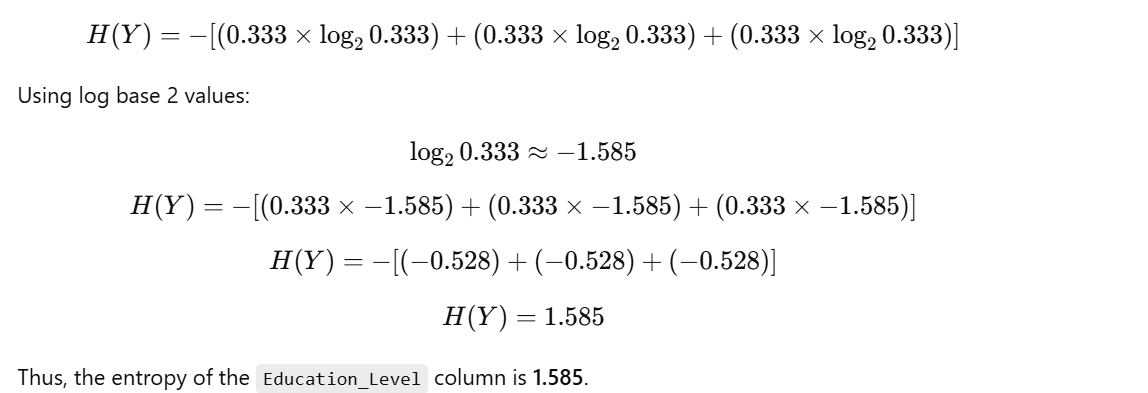

In [26]:
# Calculate entropy of target variable "Buys_Car"
y = df["Buys_Car"]
target_entropy = entropy(y)
print(f"Entropy of 'Buys_Car' (target variable): {target_entropy:.3f}")

# Calculate entropy of target variable "Education_Level"
y = df["Education_Level"]
target_entropy = entropy(y)
print(f"Entropy of 'Education_Level' (Example Column): {target_entropy:.3f}")

Entropy of 'Buys_Car' (target variable): 0.918
Entropy of 'Education_Level' (Example Column): 1.585


In [27]:
# Function to calculate Information Gain for categorical features
def information_gain(df, feature, target):
    parent_entropy = entropy(df[target])
    unique_values = df[feature].unique()
    weighted_entropy = 0
    
    for value in unique_values:
        subset = df[df[feature] == value]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset[target])
    
    # Information Gain
    ig = parent_entropy - weighted_entropy
    return ig

Let's break down every line of this function step by step.



### **Function Definition**
```python
def information_gain(df, feature, target):
```
- **`df`**: The input dataset (Pandas DataFrame).
- **`feature`**: The categorical feature for which we want to calculate Information Gain.
- **`target`**: The target column (class label) we are trying to predict.

This function will measure **how much uncertainty (entropy) is reduced** when we split the dataset based on the given `feature`.



### **Step 1: Compute Parent Entropy**
```python
parent_entropy = entropy(df[target])
```
- Calls the `entropy` function on the **target column**.
- The entropy of the target column represents the **initial uncertainty** in classification before splitting.

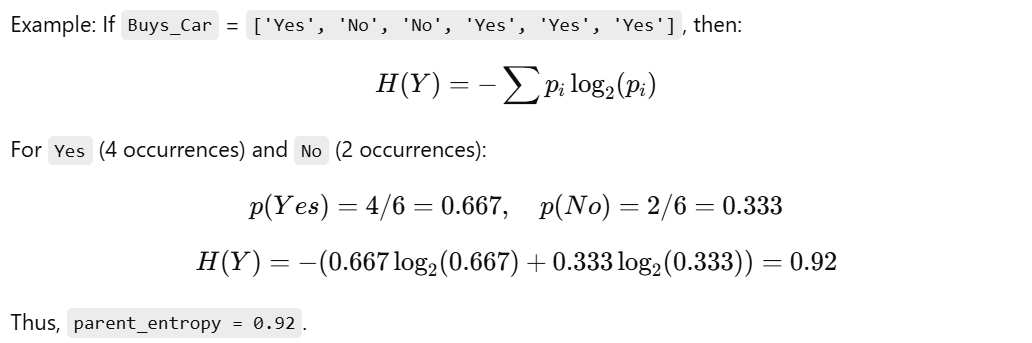

### **Step 2: Get Unique Feature Values**
```python
unique_values = df[feature].unique()
```
- Retrieves **all unique categories** in the selected `feature`.

Example:
If `feature = Education_Level`, and the column contains:

```python
['Bachelor', 'Master', 'Master', 'PhD', 'PhD', 'Bachelor']
```
Then:
```python
unique_values = ['Bachelor', 'Master', 'PhD']
```
This means we will **split** the dataset into three groups.



### **Step 3: Initialize Weighted Entropy**
```python
weighted_entropy = 0
```
- Initializes a variable `weighted_entropy` to **accumulate** the entropy contribution from each category.



### **Step 4: Loop Over Each Unique Value**
```python
for value in unique_values:
```
- Loops through each category in the feature.
- For each category, we **calculate entropy** of the subset that contains only that category.



### **Step 5: Get Subset of Data**
```python
subset = df[df[feature] == value]
```
- Filters the dataset where the feature equals the current category.

Example:
If `feature = Education_Level` and `value = "Bachelor"`, then:

```python
subset = df[df['Education_Level'] == 'Bachelor']
```
This results in a **filtered DataFrame** containing only rows where `Education_Level == Bachelor`.



### **Step 6: Compute Weighted Entropy**
```python
weighted_entropy += (len(subset) / len(df)) * entropy(subset[target])
```
- **`len(subset) / len(df)`**: The proportion of rows belonging to this category.
- **`entropy(subset[target])`**: Computes entropy for the subset's `target` values.
- **Multiplication**: The entropy is **weighted** by the size of the subset.



### **Step 7: Compute Information Gain**
```python
ig = parent_entropy - weighted_entropy
```
- Subtracts the weighted entropy from the **original (parent) entropy**.
- This gives us the **Information Gain** → how much **uncertainty (entropy) is reduced** by splitting on this feature.



### **Step 8: Return Information Gain**
```python
return ig
```
- The function returns the computed **Information Gain** for the given feature.


## **Example Walkthrough**
### **Given Dataset**
| Index | Education_Level | Buys_Car |
|--------|---------------|---------|
| 0      | Bachelor      | Yes     |
| 1      | Master        | No      |
| 2      | Master        | No      |
| 3      | PhD           | Yes     |
| 4      | PhD           | Yes     |
| 5      | Bachelor      | Yes     |

### **Step 1: Compute Parent Entropy**
We already computed **entropy of `Buys_Car`**:

H(Y) = 0.92

### **Step 2: Unique Feature Values**
```python
unique_values = ['Bachelor', 'Master', 'PhD']
```

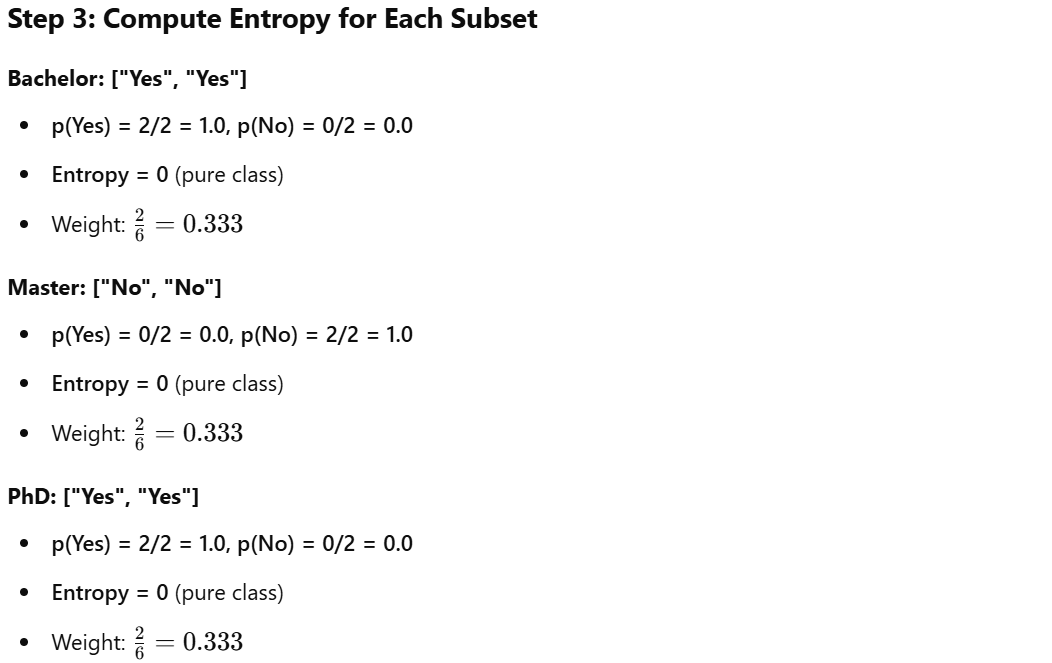

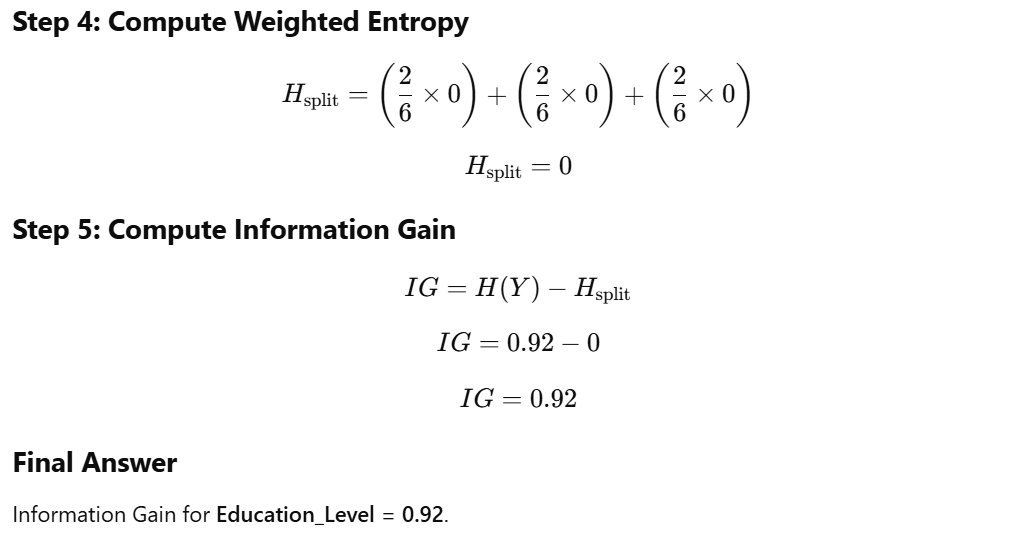

In [28]:
# Compute Information Gain for each feature
features = ["Education_Level", "Region", "Marital_Status", "Vehicle_Type", "Employment_Status"]
entropy_results = []

for feature in features:
    ig = information_gain(df, feature, "Buys_Car")
    entropy_results.append({
        "Feature": feature,
        "IG": round(ig, 3)
    })

In [29]:
# Convert results to DataFrame
entropy_results_df = pd.DataFrame(entropy_results)

# Print the results
print("\nInformation Gain (based on Entropy):")
print(entropy_results_df)


Information Gain (based on Entropy):
             Feature     IG
0    Education_Level  0.918
1             Region  0.126
2     Marital_Status  0.126
3       Vehicle_Type  0.126
4  Employment_Status  0.377


In [30]:
# Best feature based on IG
best_ig_feature = entropy_results_df.loc[entropy_results_df["IG"].idxmax()]
print("\nBest feature based on IG:", best_ig_feature["Feature"], "with Information Gain:", best_ig_feature["IG"])


Best feature based on IG: Education_Level with Information Gain: 0.918


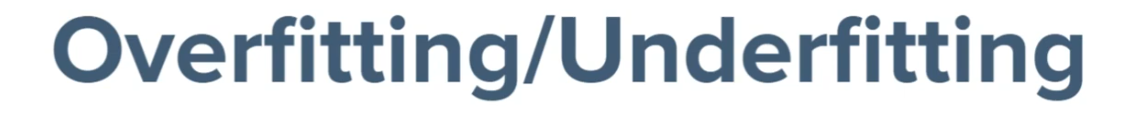

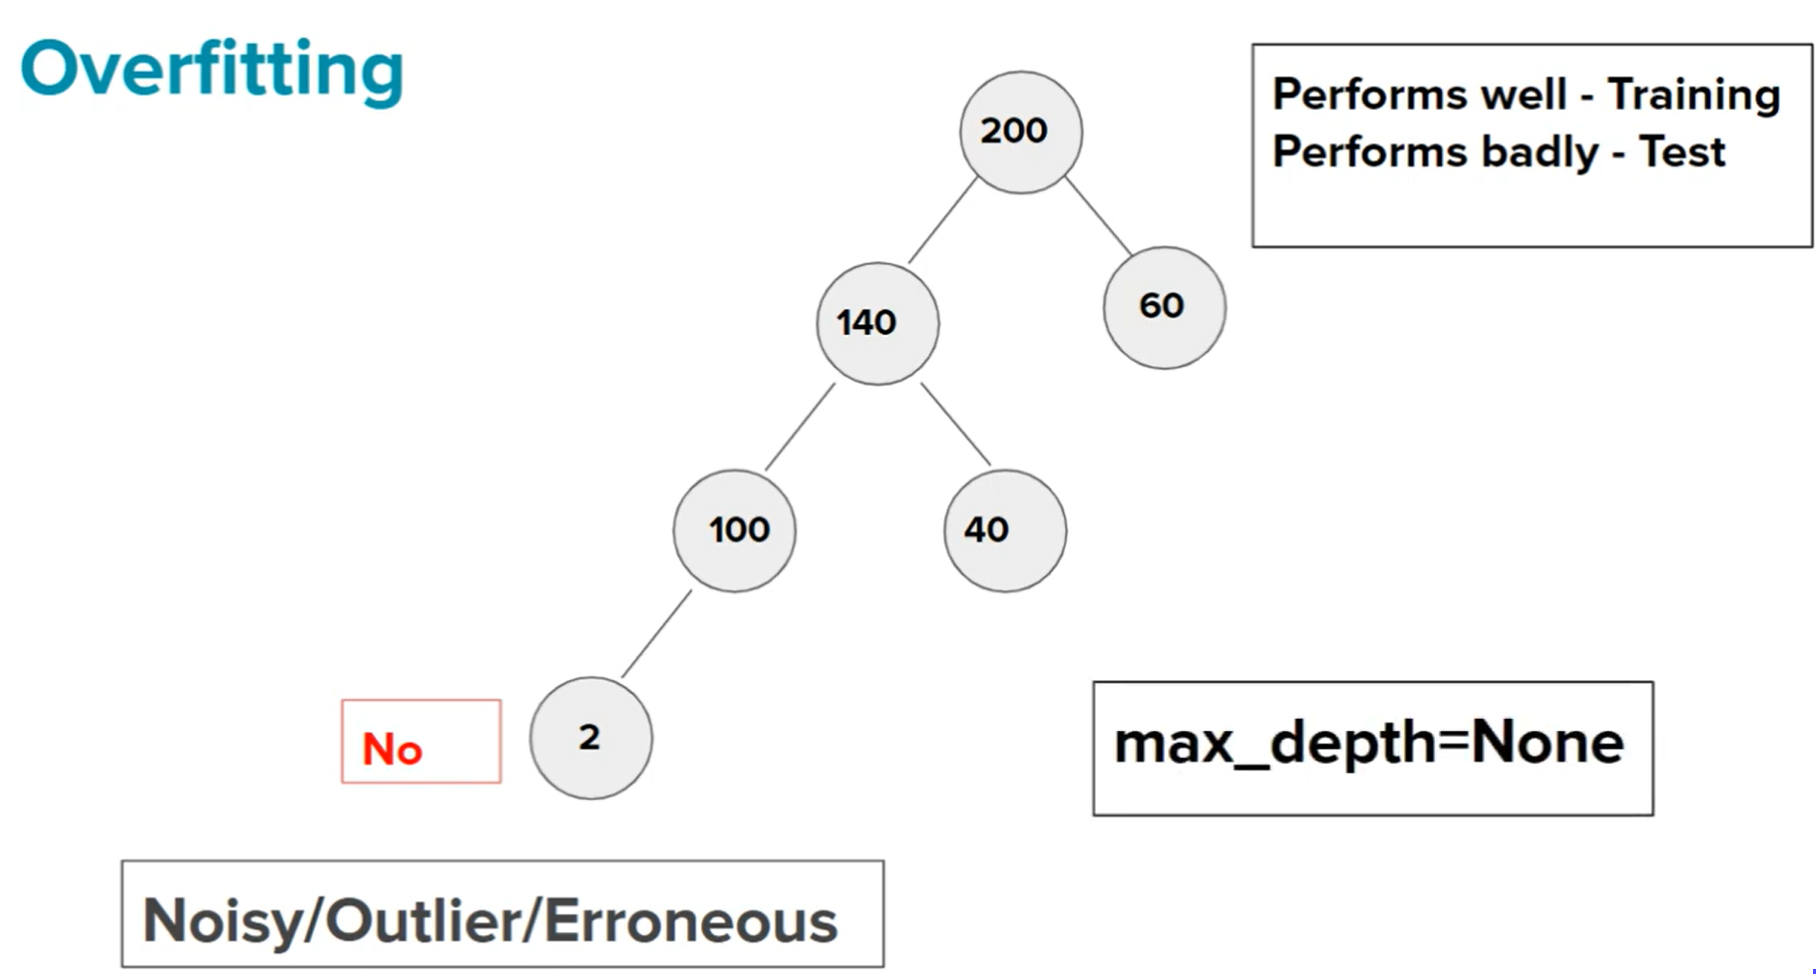

### **What is Overfitting?**  
- Overfitting occurs when a model learns too much from training data, including noise and outliers.  
- It performs very well on training data but fails on new test data.  

Think of it like a student who memorizes answers instead of understanding concepts.  
- In an exam with the same questions as practice, they score 100% (training).  
- But in a new exam (test), they struggle and perform badly.  


### **What’s Happening in the Image?**  
- The tree has too many splits, making it unnecessarily complex.  
- It even makes a decision for noisy or outlier data (value = 2 at the bottom left).  
- The setting `max_depth=None` means no limit on tree depth, leading to excessive splits.  

Imagine teaching a child to recognize animals.  
- If you say, **"Dogs have four legs and fur,"** the child can recognize most dogs.  
- But if you say, **"Only brown dogs with a specific spot are dogs,"** the child will only recognize those specific dogs and miss others. This is overfitting.  


### **Why is Overfitting Bad?**  
- The model fits perfectly to training data, even learning noise.  
- It fails to generalize well on new data, resulting in poor test performance.  
- It has high variance, meaning it is too sensitive to small changes in data.  

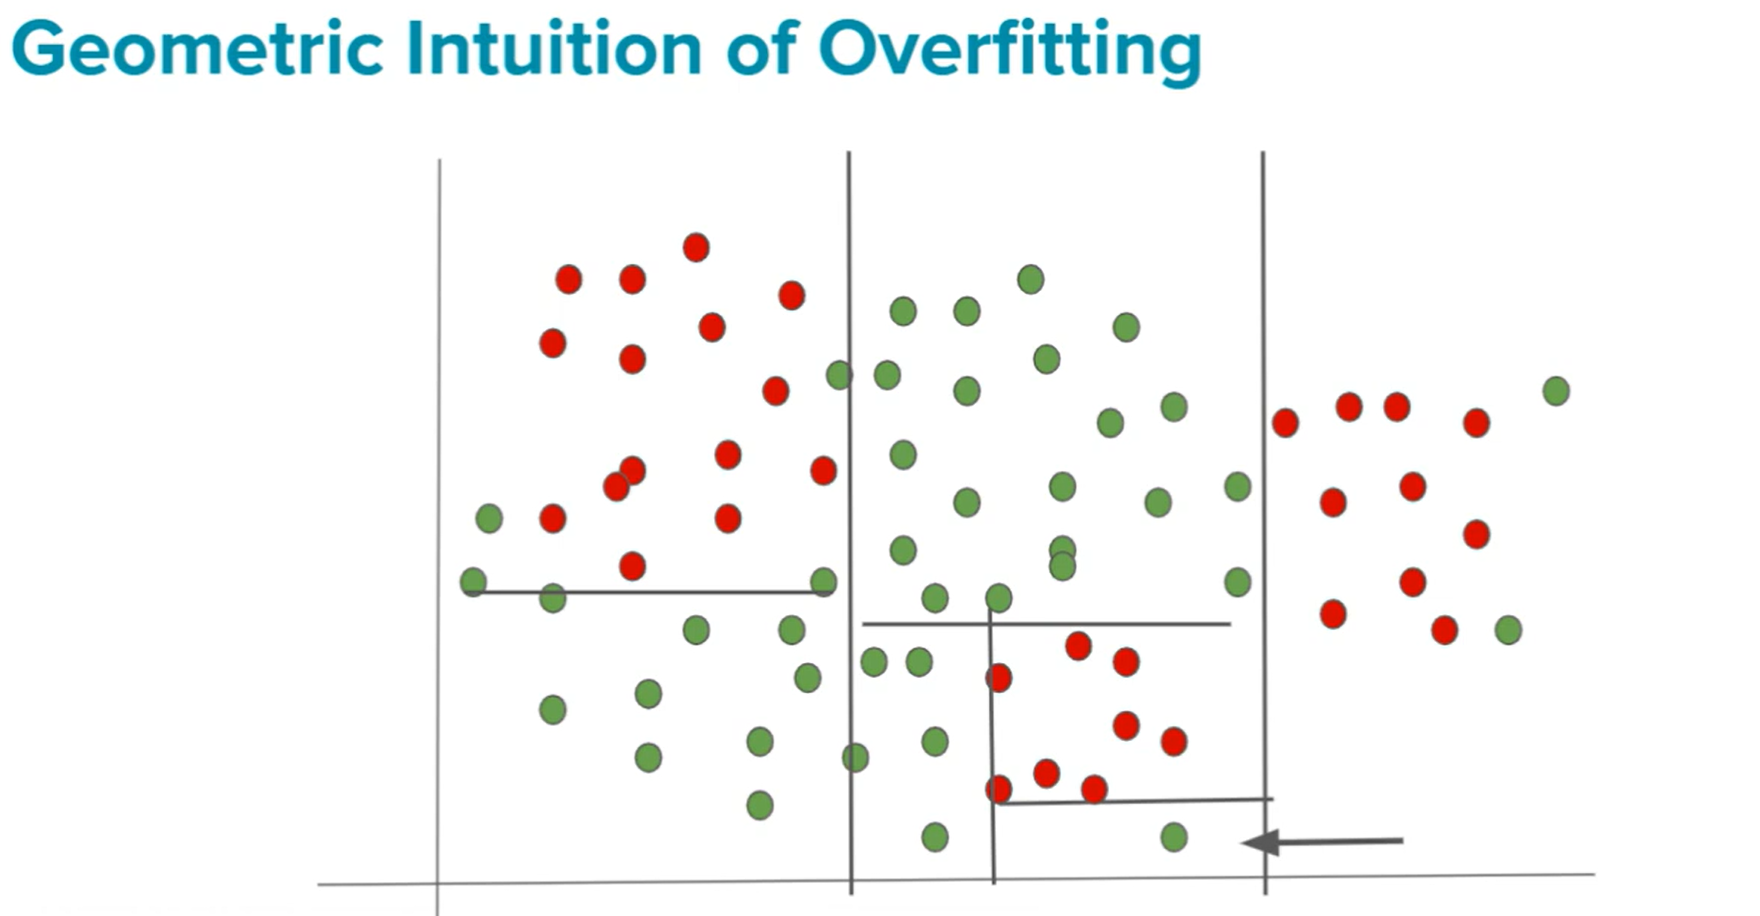

# Importing Libraries

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# 1. Generate a synthetic dataset (moons dataset for classification)

In [132]:
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

# 2. Split dataset into training and test sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Create a Decision Tree with no depth limit (Overfitting)

In [34]:
overfit_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# 4. Function to plot decision boundary

In [35]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.RdYlGn)
    plt.title(title)
    plt.show()

# 5. Visualize decision boundary of the overfitted model

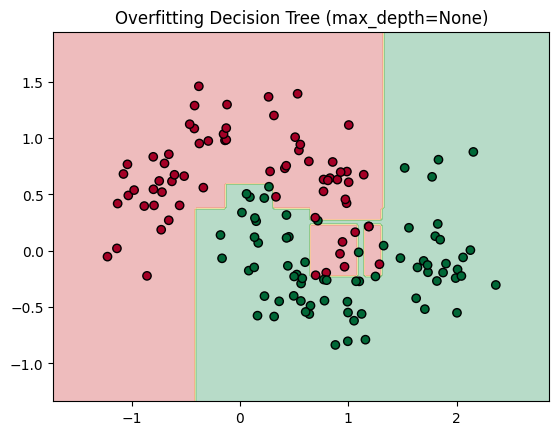

In [36]:
plot_decision_boundary(overfit_tree, X_train, y_train, "Overfitting Decision Tree (max_depth=None)")

# 6. Display the tree structure

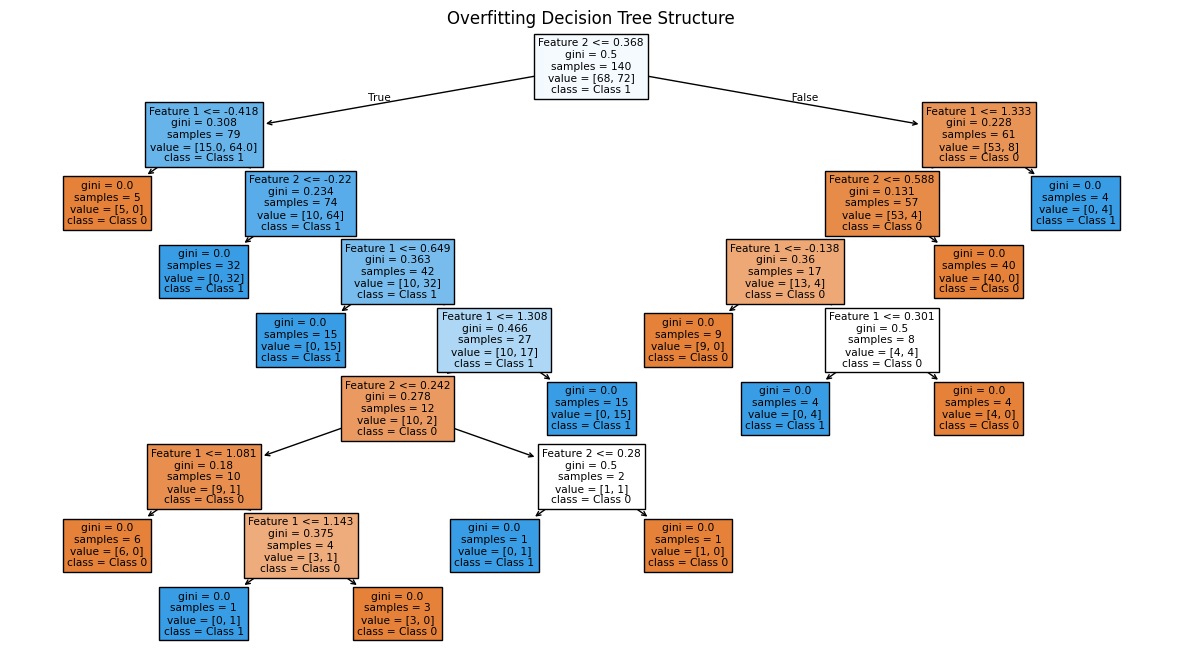

In [37]:
plt.figure(figsize=(15, 8))
plot_tree(overfit_tree, filled=True, feature_names=["Feature 1", "Feature 2"], class_names=["Class 0", "Class 1"])
plt.title("Overfitting Decision Tree Structure")
plt.show()

# 7. Evaluate model performance

In [38]:
train_acc = overfit_tree.score(X_train, y_train)
test_acc = overfit_tree.score(X_test, y_test)

# 8. Accuracy

In [39]:
print(f"Training Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")

Training Accuracy: 1.00
Test Accuracy: 0.92


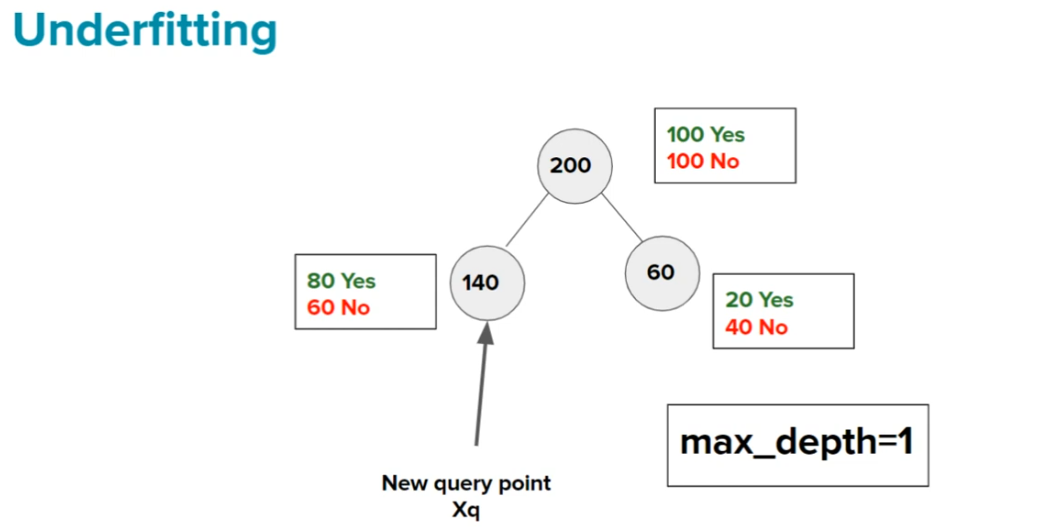

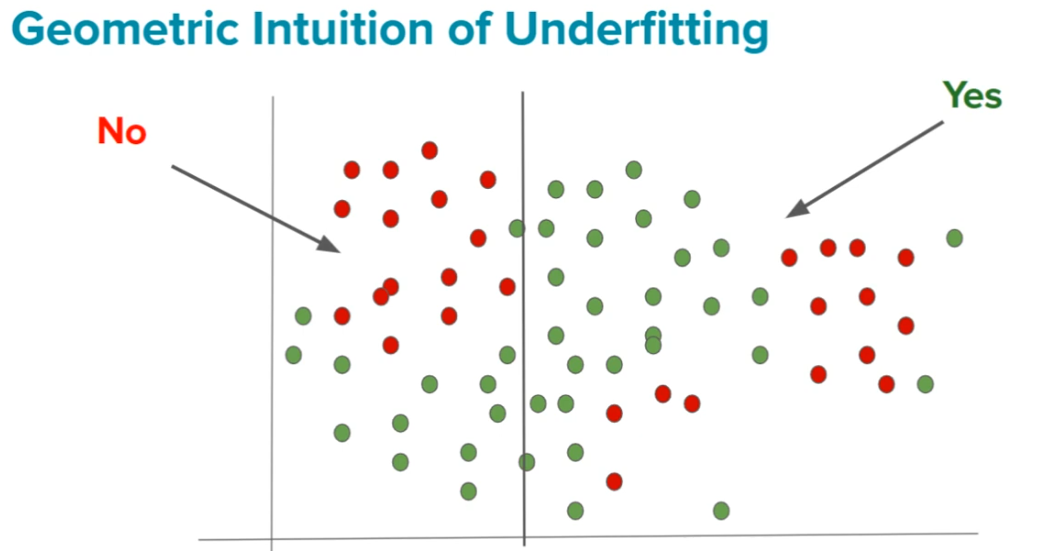

# Using about X and y data

# Create a Decision Tree with depth limit 1 (Underfitting)

In [40]:
underfit_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
underfit_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1, random_state=42)

In [41]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.RdYlGn)
    plt.title(title)
    plt.show()

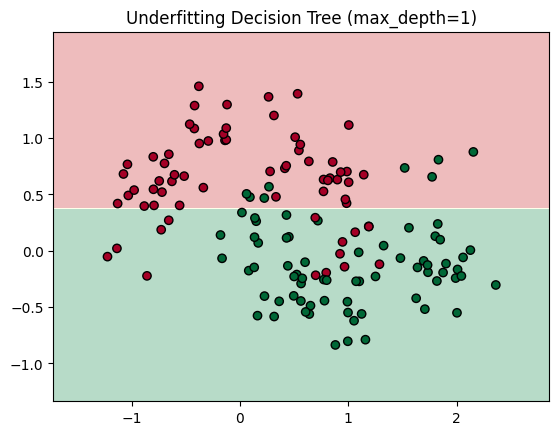

In [42]:
plot_decision_boundary(underfit_tree, X_train, y_train, "Underfitting Decision Tree (max_depth=1)")

In [43]:
underfit_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
underfit_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1, random_state=42)

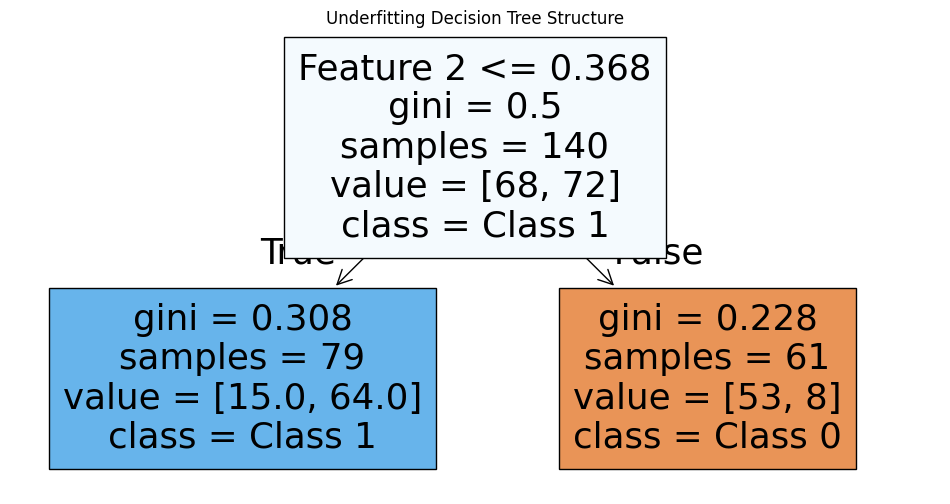

In [44]:
plt.figure(figsize=(12, 6))
plot_tree(underfit_tree, filled=True, feature_names=["Feature 1", "Feature 2"], class_names=["Class 0", "Class 1"])
plt.title("Underfitting Decision Tree Structure")
plt.show()

In [45]:
train_acc1 = underfit_tree.score(X_train, y_train)
test_acc1 = underfit_tree.score(X_test, y_test)

In [46]:
print(f"Training Accuracy: {train_acc1:.2f}")
print(f"Test Accuracy: {test_acc1:.2f}")

Training Accuracy: 0.84
Test Accuracy: 0.82


### **Hyperparameters in Decision Trees**
Decision trees have several hyperparameters that control their complexity and performance. Proper tuning of these hyperparameters can help prevent **overfitting** or **underfitting**.


### **1. Important Hyperparameters**
#### **A. Controlling Tree Depth (Pre-Pruning)**
| Hyperparameter | Description | Effect |
|---------------|-------------|--------|
| `max_depth` | Maximum depth of the tree | Limits complexity to prevent overfitting |
| `min_samples_split` | Minimum samples required to split a node | Prevents unnecessary splits |
| `min_samples_leaf` | Minimum samples per leaf node | Ensures each leaf has enough data |
| `max_leaf_nodes` | Limits the number of leaf nodes | Controls model complexity |

**Example:**
```python
DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5)
```
- Limits depth to **5** to prevent overfitting.
- Requires **at least 10 samples** to split a node.
- Requires **at least 5 samples** in each leaf.


#### **B. Splitting Criteria (Impurity Measures)**
| Hyperparameter | Description | Options |
|---------------|-------------|---------|
| `criterion` | Function to measure the quality of a split | `"gini"` (default), `"entropy"` |

- **Gini Impurity**: Measures how often a randomly chosen element would be incorrectly classified.  
- **Entropy**: Measures information gain (higher gain is better for splitting).

**Example:**
```python
DecisionTreeClassifier(criterion="entropy")
```


#### **C. Handling Features**
| Hyperparameter | Description | Effect |
|---------------|-------------|--------|
| `max_features` | Number of features to consider for splitting | Reduces variance, speeds up training |
| `random_state` | Controls randomness of splits | Ensures reproducibility |

**Example:**
```python
DecisionTreeClassifier(max_features="sqrt", random_state=42)
```
- Uses only a subset (`sqrt(num_features)`) for each split.
- Makes results reproducible.


#### **D. Post-Pruning (Reducing Overfitting)**
| Hyperparameter | Description | Effect |
|---------------|-------------|--------|
| `ccp_alpha` | Complexity parameter for pruning | Higher value → more pruning (simpler tree) |

**Example:**
```python
DecisionTreeClassifier(ccp_alpha=0.01)
```
- Prunes small branches that do not improve accuracy significantly.


### **2. Choosing the Right Hyperparameters**
- **Prevent Overfitting:** Use `max_depth`, `min_samples_split`, `min_samples_leaf`, and `ccp_alpha`.
- **Improve Generalization:** Use `max_features` and `random_state`.
- **Speed up Training:** Use `max_features` and restrict depth.

# Regression Tree : https://youtu.be/g9c66TUylZ4?si=uIlpLT_pvrMwxKqn

# Prune Regression Trees : https://youtu.be/D0efHEJsfHo?si=E9SBLMEDE-9BDUs7

# Thank You